# LUT Transformer V3 (Softmax Attention)

Based on exp184: V3 architecture with LUT score attention + value LUT + softmax@V + out_proj LUT.

In [1]:
import os, sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

torch.set_float32_matmul_precision('high')
import warnings
import torch._dynamo
torch._dynamo.config.cache_size_limit = 128
warnings.filterwarnings(
    "ignore",
    message=".*has_cuda.*deprecated.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*has_cudnn.*deprecated.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*has_mps.*deprecated.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*has_mkldnn.*deprecated.*"
)

device = 'cuda:0'
torch.manual_seed(42)
print(torch.__version__)

2.11.0+cu130


## Data preparation

In [2]:
import gdown
url = 'https://drive.google.com/file/d/1vWjyIpU6wvCPtx2OdV_4M3MXX6FsOpxV/view'
output = 'fineweb_texts.txt'
if not os.path.exists(output):
    gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1vWjyIpU6wvCPtx2OdV_4M3MXX6FsOpxV
From (redirected): https://drive.google.com/uc?id=1vWjyIpU6wvCPtx2OdV_4M3MXX6FsOpxV&confirm=t&uuid=3bf50077-3657-476f-b0be-c9d5edbf3450
To: /home/starost/spiky/workbooks/fineweb_texts.txt
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 245M/245M [00:02<00:00, 104MB/s]


In [3]:
CONTEXT_SIZE = 32
VOCAB_SIZE = 257
BOS_ID = 256
TESTING_LENGTH = 10_000

from spiky.util.text_snippet_sampler import TextSnippetSampler
sampler = TextSnippetSampler('fineweb_texts.txt', CONTEXT_SIZE, TESTING_LENGTH, device, random_seed=1)

batch = sampler.sample_training_batch(2)
print(sampler.batch_to_text(batch))

['crowd control at Beatles concert', 'shiping other gods. A representa']


## Model definition

V3 Softmax architecture per block:
- Score LUT (LUTAttentionV3) → raw attention scores [B, T, T, H, 1]
- Value LUT (per-token) → values [B, T, H, d_v]
- softmax(scores) @ V → weighted values
- LayerNorm → Out-proj LUT (H*d_v → E)
- Residual + LayerNorm

In [44]:
cfg = {
    'embedding_dim': 32,
    'positional_dim': 16,
    'num_layers': 6,
    'n_heads': 4,
    'd_v': 16,
    'attention_nap': 10,
    'attention_tph': 32,
    'value_nap': 6,
    'value_tph': 128,
    'out_proj_nap': 8,
    'out_proj_tph': 128,
    'anchor_sampling_policy': 'full_coverage',
    'initial_weights_noise': 0.001,
}

In [52]:
from spiky.lutorch.multi_head_lut import MultiHeadLut
from spiky.lutorch.lut_helpers import UncertaintyMode, AnchorSamplingPolicy
from spiky.lutorch.lut_attention import LUTAttentionV3


def make_score_attn(seed_offset=0):
    E, P, H = cfg['embedding_dim'], cfg['positional_dim'], cfg['n_heads']
    lut = MultiHeadLut(
        input_dim=2*E+P, n_heads=H, n_outputs=1,
        n_anchor_pairs=cfg['attention_nap'], tables_per_head=cfg['attention_tph'],
        smooth_mode=False, n_alternatives=1,
        normalize_weights=False, calibrate_output=False,
        anchor_sampling_policy=AnchorSamplingPolicy(cfg['anchor_sampling_policy']),
        initial_weights_noise=cfg['initial_weights_noise'],
        uncertainty_mode=UncertaintyMode.INVERSE_L1,
        random_seed=42+seed_offset, device=device, recompute_in_backward=True,
    )
    return LUTAttentionV3(lut, seq_len=CONTEXT_SIZE, causal=True, include_diagonal=True)


def make_value_lut(seed_offset=200):
    E, H, d_v = cfg['embedding_dim'], cfg['n_heads'], cfg['d_v']
    return MultiHeadLut(
        input_dim=E, n_heads=H, n_outputs=d_v,
        n_anchor_pairs=cfg['value_nap'], tables_per_head=cfg['value_tph'],
        smooth_mode=False, n_alternatives=3,
        normalize_weights=False, calibrate_output=False,
        anchor_sampling_policy=AnchorSamplingPolicy(cfg['anchor_sampling_policy']),
        initial_weights_noise=cfg['initial_weights_noise'],
        uncertainty_mode=UncertaintyMode.INVERSE_L1,
        random_seed=42+seed_offset, device=device, recompute_in_backward=True,
    )


def make_out_proj(seed_offset=400):
    E, H, d_v = cfg['embedding_dim'], cfg['n_heads'], cfg['d_v']
    return MultiHeadLut(
        input_dim=H*d_v, n_heads=1, n_outputs=E,
        n_anchor_pairs=cfg['out_proj_nap'], tables_per_head=cfg['out_proj_tph'],
        smooth_mode=False, n_alternatives=3,
        normalize_weights=False, calibrate_output=False,
        anchor_sampling_policy=AnchorSamplingPolicy(cfg['anchor_sampling_policy']),
        initial_weights_noise=cfg['initial_weights_noise'],
        uncertainty_mode=UncertaintyMode.INVERSE_L1,
        random_seed=42+seed_offset, device=device, recompute_in_backward=True,
    )


class LUTBlock(nn.Module):
    def __init__(self, layer_idx):
        super().__init__()
        H, d_v = cfg['n_heads'], cfg['d_v']
        self.score_attn = make_score_attn(seed_offset=layer_idx)
        self.value_lut = make_value_lut(seed_offset=200+layer_idx)
        self.out_proj = make_out_proj(seed_offset=400+layer_idx)
        self.attn_norm = nn.LayerNorm(H*d_v)
        self.norm = nn.LayerNorm(cfg['embedding_dim'])
        self.H, self.d_v = H, d_v

    def forward(self, x, rel_pe):
        B, T, E = x.shape
        H, d_v = self.H, self.d_v
        raw_scores = self.score_attn(x, rel_pe).squeeze(-1).permute(0, 3, 1, 2)
        attn_weights = F.softmax(raw_scores, dim=-1)
        v = self.value_lut(x.reshape(B*T, E)).reshape(B, T, H, d_v).permute(0, 2, 1, 3)
        attn_out = (attn_weights @ v).permute(0, 2, 1, 3).reshape(B, T, H*d_v)
        attn_out = self.attn_norm(attn_out)
        proj = self.out_proj(attn_out.reshape(B*T, H*d_v)).squeeze(1).reshape(B, T, E)
        return x + self.norm(proj)


class LUTTransformerV3(nn.Module):
    def __init__(self):
        super().__init__()
        E, P = cfg['embedding_dim'], cfg['positional_dim']
        self.token_embedder = nn.Embedding(VOCAB_SIZE, E)
        self.token_embedder.weight.data.uniform_(-0.1, 0.1)
        self.rel_pe = nn.Parameter(torch.randn(CONTEXT_SIZE, P) * 0.1)
        self.layers = nn.ModuleList([LUTBlock(i) for i in range(cfg['num_layers'])])
        self.unembedder = nn.Linear(E, VOCAB_SIZE, bias=False)

    def forward(self, tokens):
        x = self.token_embedder(tokens)
        for layer in self.layers:
            x = layer(x, self.rel_pe)
        return self.unembedder(x)

## Evaluation & generation helpers

In [53]:
def generate_text(model, prefix, length=80):
    ctx = list(prefix.encode("utf-8"))
    for _ in range(length):
        x = torch.zeros([1, CONTEXT_SIZE], dtype=torch.long, device=device)
        x[0, 0] = BOS_ID
        trunc = ctx[-(CONTEXT_SIZE-1):]
        if trunc:
            x[0, -len(trunc):] = torch.tensor(trunc, dtype=torch.long, device=device)
        with torch.no_grad():
            logits = model(x)
        probs = torch.softmax(logits[:, -1, :256], dim=-1)[0]
        ctx.append(torch.multinomial(probs, 1).item())
    return bytes([c for c in ctx if 0 <= c < 256]).decode("utf-8", errors="replace")


def evaluate(model):
    model.eval()
    losses = []
    with torch.no_grad():
        for batch in sampler.testing_batches_iterator(128):
            inp = torch.empty_like(batch, dtype=torch.long)
            inp[:, 0] = BOS_ID
            inp[:, 1:] = batch[:, :-1].long()
            logits = model(inp)
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.reshape(B*T, V), batch.long().reshape(B*T))
            losses.append(loss.item())
    val_loss = sum(losses) / len(losses)
    print(f"[GEN]: {generate_text(model, 'Once upon a time ')}")
    model.train()
    return val_loss

## Training

In [54]:
model = LUTTransformerV3().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

Parameters: 10,241,728


In [55]:
import math
from tqdm.notebook import tqdm

n_steps = 50000
batch_size = 64
lr = 0.001
warmup_fraction = 0.1

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# def get_lr_scale(step):
#     warmup = int(warmup_fraction * n_steps)
#     if step < warmup:
#         return step / max(warmup, 1)
#     progress = (step - warmup) / max(n_steps - warmup, 1)
#     return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress))

def get_lr_scale(step):
    return 1.0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, get_lr_scale)

train_losses, val_losses, val_steps = [], [], []
ema = None

model.train()
for step in tqdm(range(n_steps)):
    x = sampler.sample_training_batch(batch_size).long()
    inp = torch.empty_like(x)
    inp[:, 0] = BOS_ID
    inp[:, 1:] = x[:, :-1]

    logits = model(inp)
    B, T, V = logits.shape
    loss = F.cross_entropy(logits.reshape(B*T, V), x.reshape(B*T))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    lv = loss.item()
    ema = lv if ema is None else 0.99 * ema + 0.01 * lv

    if step % 100 == 0:
        print(f"step {step:6d} | loss={ema:.4f} | lr={scheduler.get_last_lr()[0]:.2e}")

    if step % 1000 == 0:
        val = evaluate(model)
        print(f"[VAL] step {step}: {val:.4f}")
        train_losses.append(ema)
        val_losses.append(val)
        val_steps.append(step)

  0%|          | 0/50000 [00:00<?, ?it/s]

step      0 | loss=6.4788 | lr=1.00e-03
[GEN]: Once upon a time ee p� eoeo�opp�eoopeoee� �e�o�p  opo��e  o�p�po�po� opo��oo�� poo�ppp���oo� p o
[VAL] step 0: 7.6557
step    100 | loss=4.3292 | lr=1.00e-03
step    200 | loss=3.1463 | lr=1.00e-03
step    300 | loss=2.5681 | lr=1.00e-03
step    400 | loss=2.2715 | lr=1.00e-03
step    500 | loss=2.1099 | lr=1.00e-03
step    600 | loss=2.0138 | lr=1.00e-03
step    700 | loss=1.9581 | lr=1.00e-03
step    800 | loss=1.9114 | lr=1.00e-03
step    900 | loss=1.8861 | lr=1.00e-03
step   1000 | loss=1.8585 | lr=1.00e-03
[GEN]: Once upon a time is Hther when after derm 1ultame and for conneck (the (997%; were not of access.
[VAL] step 1000: 1.8301
step   1100 | loss=1.8360 | lr=1.00e-03
step   1200 | loss=1.8176 | lr=1.00e-03
step   1300 | loss=1.8045 | lr=1.00e-03
step   1400 | loss=1.7948 | lr=1.00e-03
step   1500 | loss=1.7837 | lr=1.00e-03
step   1600 | loss=1.7769 | lr=1.00e-03
step   1700 | loss=1.7670 | lr=1.00e-03
step   1800 | loss=1.7613

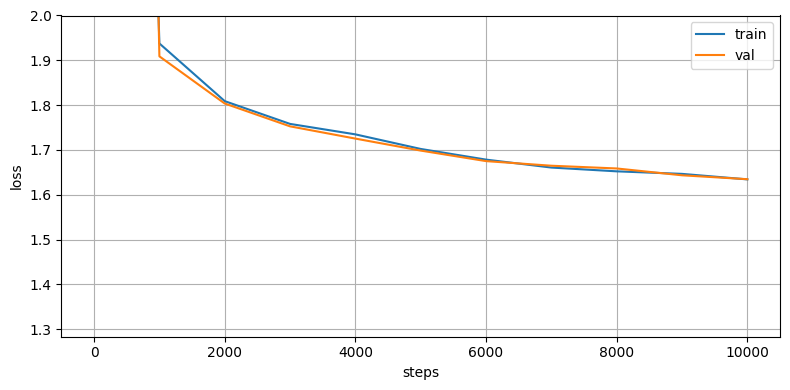

Final val loss: 1.6347


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(val_steps, train_losses, label='train')
plt.plot(val_steps, val_losses, label='val')
plt.xlabel('steps')
plt.ylabel('loss')
plt.legend()
plt.ylim(top=2.0)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final val loss: {val_losses[-1]:.4f}")

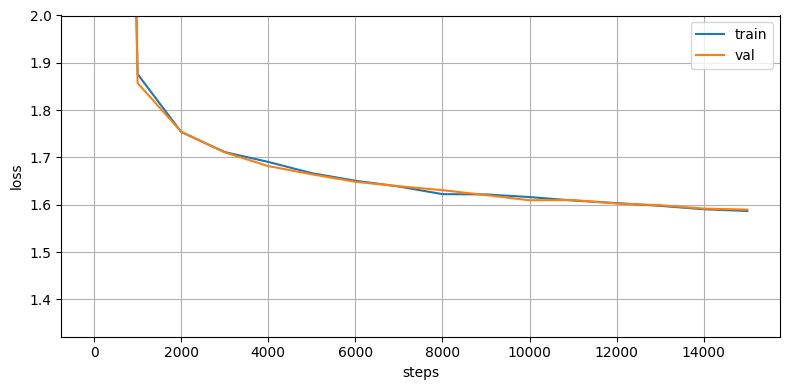

Final val loss: 1.5899


In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(val_steps, train_losses, label='train')
plt.plot(val_steps, val_losses, label='val')
plt.xlabel('steps')
plt.ylabel('loss')
plt.legend()
plt.ylim(top=2.0)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final val loss: {val_losses[-1]:.4f}")

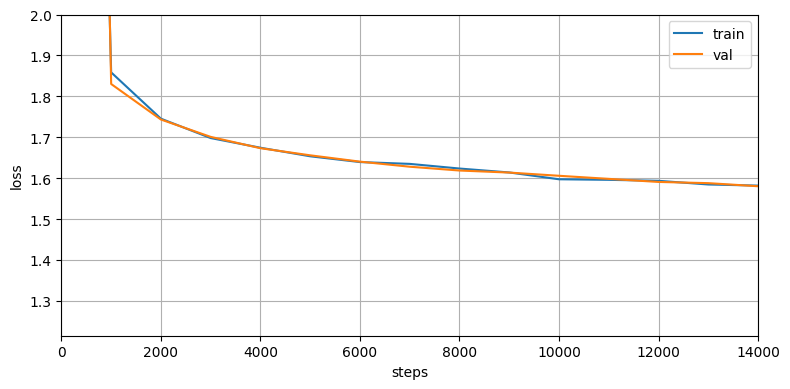

Final val loss: 1.5256


In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(val_steps, train_losses, label='train')
plt.plot(val_steps, val_losses, label='val')
plt.xlabel('steps')
plt.ylabel('loss')
plt.legend()
plt.ylim(top=2.0)
plt.xlim(left=0.0, right=14000.0)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final val loss: {val_losses[-1]:.4f}")